In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:

# --- CARGA Y PREPROCESAMIENTO ---
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [3]:
# Muestreo balanceado para que KNN y el Stacking fluyan rápido (Proporción 1:3)
fraud = train_df[train_df['is_fraud'] == 1]
non_fraud = train_df[train_df['is_fraud'] == 0].sample(n=len(fraud) * 3, random_state=42)
train_balanced = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

def preprocess(df):
    cols = ['amt', 'category', 'state', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'age', 'hour', 'day_of_week']
    X = df[cols].copy()
    le = LabelEncoder()
    for col in ['category', 'state']:
        X[col] = le.fit_transform(X[col].astype(str))
    return X

X_train = preprocess(train_balanced)
y_train = train_balanced['is_fraud']
X_test = preprocess(test_df)
y_test = test_df['is_fraud']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# --- MODELO 1: STACKING ENSEMBLE (El obligatorio) ---
print("Entrenando Stacking (LR + DT + KNN)...")

base_models = [
    ('lr', LogisticRegression(class_weight='balanced')),
    ('dt', DecisionTreeClassifier(max_depth=2, class_weight='balanced')),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(), # Metamodelo
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train_scaled, y_train)

Entrenando Stacking (LR + DT + KNN)...


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('dt', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of 

In [14]:

# Evaluación Stacking
y_pred_st = stacking_model.predict(X_test_scaled)
y_prob_st = stacking_model.predict_proba(X_test_scaled)[:, 1]
print("\n=== RESULTADOS STACKING ===")
print(classification_report(y_test, y_pred_st))


=== RESULTADOS STACKING ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     63915
           1       0.11      0.76      0.20       334

    accuracy                           0.97     64249
   macro avg       0.56      0.87      0.59     64249
weighted avg       0.99      0.97      0.98     64249




Entrenando Random Forest independiente...
Entrenando XGBoost independiente...

=== RESULTADOS RANDOM FOREST ===
PR-AUC: 0.7532
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     63915
           1       0.27      0.92      0.42       334

    accuracy                           0.99     64249
   macro avg       0.64      0.95      0.71     64249
weighted avg       1.00      0.99      0.99     64249


=== RESULTADOS XGBOOST ===
PR-AUC: 0.8176
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     63915
           1       0.22      0.96      0.36       334

    accuracy                           0.98     64249
   macro avg       0.61      0.97      0.67     64249
weighted avg       1.00      0.98      0.99     64249



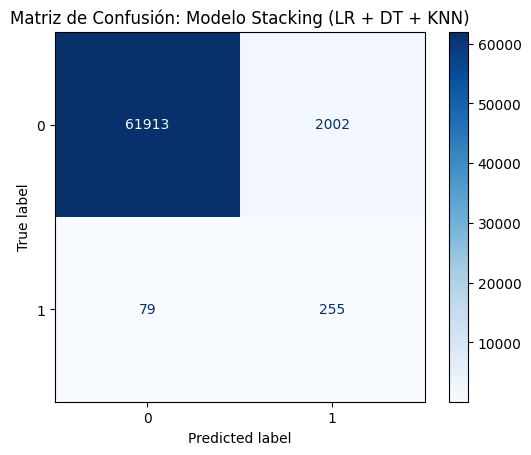

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- MODELO 2: RANDOM FOREST ---
print("\nEntrenando Random Forest independiente...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- MODELO 3: XGBOOST ---
print("Entrenando XGBoost independiente...")
xgb_model = XGBClassifier(scale_pos_weight=3, n_estimators=100, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# --- COMPARATIVA FINAL ---
for name, model in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    print(f"\n=== RESULTADOS {name.upper()} ===")
    print(f"PR-AUC: {auc(recall, precision):.4f}")
    print(classification_report(y_test, preds))

# Visualización de la Matriz de Confusión del Stacking para la defensa
ConfusionMatrixDisplay.from_estimator(stacking_model, X_test_scaled, y_test, cmap='Blues')
plt.title("Matriz de Confusión: Modelo Stacking (LR + DT + KNN)")
plt.show()

VISUALIZACIÓN DEL ROC

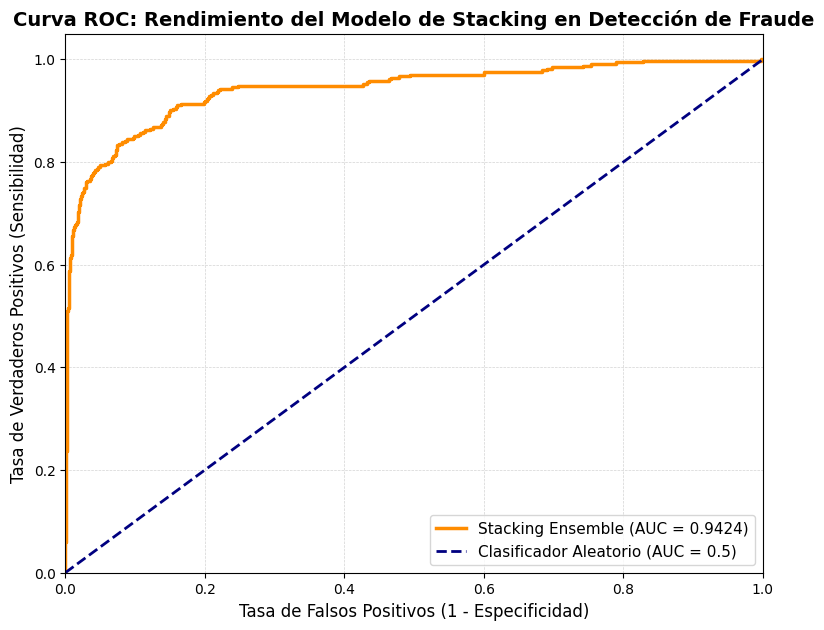

El valor del Área Bajo la Curva (AUC) es: 0.9424


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

# 1. Obtener las probabilidades del modelo Stacking para la clase 'Fraude' (1)
# stacking_clf es el modelo que entrenamos anteriormente
y_probs = stacking_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calcular los valores de la curva (Tasa de Falsos Positivos y Verdaderos Positivos)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Generar la gráfica profesional
plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Stacking Ensemble (AUC = {roc_auc:.4f})')

# Dibujar la línea diagonal de referencia (azar)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

# Configuración estética
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva ROC: Rendimiento del Modelo de Stacking en Detección de Fraude', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)

# Guardar la imagen para el PowerPoint
plt.savefig('curva_roc_trabajo_final.png', dpi=300)
plt.show()

print(f"El valor del Área Bajo la Curva (AUC) es: {roc_auc:.4f}")

--- TABLA COMPARATIVA FINAL ---


,Accuracy,F1-Score,ROC-AUC
lr,0.943626,0.118735,0.821355
dt,0.872636,0.064693,0.893880
knn,0.967968,0.176141,0.905713
STACKING (FINAL),0.967610,0.196835,0.942364


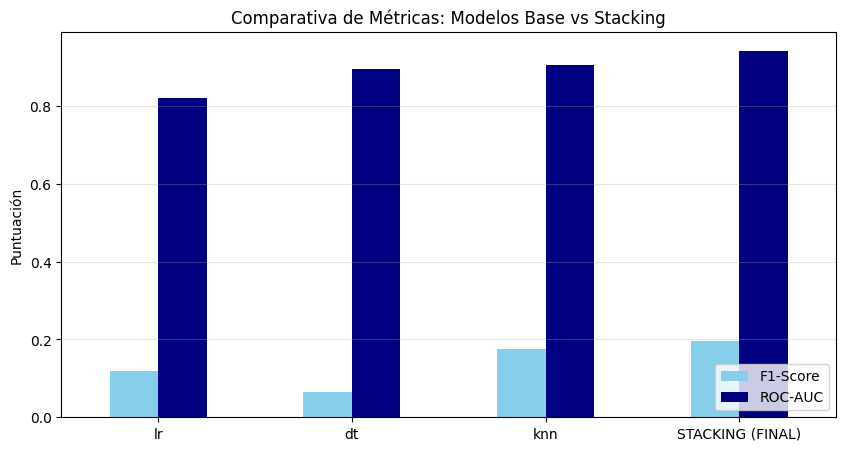

In [18]:
from sklearn.metrics import f1_score, accuracy_score

# 1. Creamos un diccionario para guardar los resultados
comparativa = {}

# 2. Evaluamos cada modelo base que forma parte del Stacking
# (Accedemos a ellos mediante .named_estimators_)
for nombre, modelo in stacking_model.named_estimators_.items():
    # Es VITAL usar X_test_scaled para que LR y KNN funcionen bien
    y_pred_individual = modelo.predict(X_test_scaled)
    
    comparativa[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred_individual),
        'F1-Score': f1_score(y_test, y_pred_individual),
        'ROC-AUC': roc_auc_score(y_test, modelo.predict_proba(X_test_scaled)[:, 1])
    }

# 3. Añadimos el resultado del Stacking (el ensamble final)
y_pred_final = stacking_model.predict(X_test_scaled)
y_prob_final = stacking_model.predict_proba(X_test_scaled)[:, 1]

comparativa['STACKING (FINAL)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'F1-Score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_prob_final)
}

# 4. Convertimos a DataFrame para que se vea como una tabla limpia
df_comparativa = pd.DataFrame(comparativa).T

print("--- TABLA COMPARATIVA FINAL ---")
display(df_comparativa) # Si usas Jupyter, display queda más bonito que print

# 5. Gráfico rápido para la presentación
df_comparativa[['F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(10,5), color=['skyblue', 'navy'])
plt.title("Comparativa de Métricas: Modelos Base vs Stacking")
plt.ylabel("Puntuación")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

--- COMPARATIVA DE MODELOS INDEPENDIENTES VS STACKING ---


,Accuracy,F1-Score,ROC-AUC,PR-AUC,MCC
Modelo,,,,,
Stacking,0.978241,0.315377,0.986025,0.451964,0.421286
Random Forest,0.987533,0.435518,0.993772,0.776366,0.509565
XGBoost,0.982101,0.358974,0.997284,0.817561,0.456636


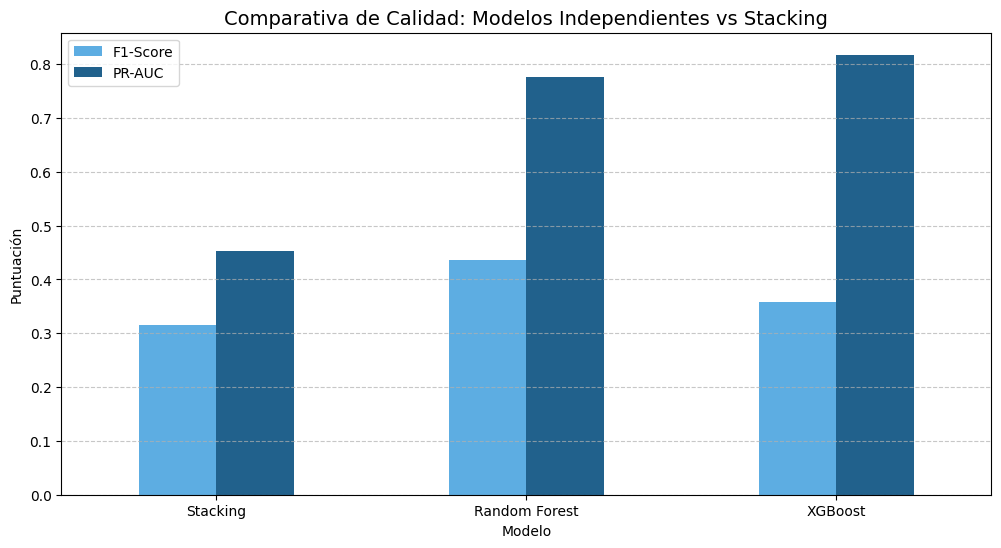

In [9]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, matthews_corrcoef, precision_recall_curve, auc

# 1. Creamos una lista con los modelos que queremos evaluar
modelos_a_comparar = [
    ('Stacking', stacking_model),
    ('Random Forest', rf_model),
    ('XGBoost', xgb_model)
]

resultados_lista = []

# 2. Iteramos para calcular métricas de cada uno
for nombre, modelo in modelos_a_comparar:
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Calcular Precision-Recall AUC (muy importante en fraude)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    # Guardamos todo en un diccionario
    resultados_lista.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': pr_auc,
        'MCC': matthews_corrcoef(y_test, y_pred)
    })

# 3. Convertimos a DataFrame para visualizarlo como tabla
df_metricas = pd.DataFrame(resultados_lista).set_index('Modelo')

print("--- COMPARATIVA DE MODELOS INDEPENDIENTES VS STACKING ---")
display(df_metricas)

# 4. Gráfico comparativo de PR-AUC y F1-Score (las más honestas para fraude)
df_metricas[['F1-Score', 'PR-AUC']].plot(kind='bar', figsize=(12, 6), color=['#5dade2', '#21618c'])
plt.title("Comparativa de Calidad: Modelos Independientes vs Stacking", fontsize=14)
plt.ylabel("Puntuación")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()